# Otimização de Agendas no SUS: Previsão de No-Shows

Este código realiza uma análise exploratória de dados (EDA) focada em entender os padrões de absenteísmo em consultas médicas na rede pública.

Vamos analisar uma base de dados reais da cidade de Vitória (ES) para explorar o comportamento de faltas com base em variáveis como:

- Idade do paciente (Age)
- Tempo de espera entre a marcação e a consulta (WaitingDays)
- Recebimento de lembretes (SMS_received)
- Condições preexistentes (Hipertensão, Diabetes, etc.)

Ao final desta etapa queremos entender o seguinte: “Quais características e comportamentos históricos mais influenciam a probabilidade de um paciente faltar à consulta?”

---
*Desenvolvido pela equipe para o projeto de Overbooking Inteligente.*

# Dataset

Foi utilizado um dataset disponível para download no Kaggle:
https://www.kaggle.com/datasets/joniarroba/noshowappointments

Este dataset, chamado de "Medical Appointment No Shows", consiste em 110.527 registros de consultas médicas da rede pública da cidade de Vitória (ES), Brasil. Os dados estão armazenados como linhas com as seguintes colunas originais:

- PatientId: identificador exclusivo do paciente.
- AppointmentID: identificador exclusivo do agendamento da consulta.
- Gender: sexo do paciente (F para feminino ou M para masculino).
- ScheduledDay: data e hora em que o paciente realizou a marcação da consulta.
- AppointmentDay: data para a qual a consulta médica foi agendada.
- Age: idade do paciente em anos.
- Neighbourhood: bairro de Vitória (ES) onde a unidade de saúde está localizada.
- Scholarship: indica se o paciente é beneficiário do programa social Bolsa Família (1 = Sim, 0 = Não).
- Hipertension, Diabetes, Alcoholism, Handcap: variáveis binárias (1 ou 0) que indicam se o paciente possui diagnóstico de hipertensão, diabetes, alcoolismo ou alguma deficiência.
- SMS_received: indica se o paciente recebeu uma ou mais mensagens de texto como lembrete da consulta (1 = Sim, 0 = Não).
- No-show: variável alvo que indica se o paciente faltou à consulta ("Yes" = Faltou; "No" = Compareceu).

*Nota: Durante a fase de Engenharia de Dados, criaremos também a variável "WaitingDays" (Dias de Espera), calculada a partir da diferença entre o ScheduledDay e o AppointmentDay.*

# Importar as Bibliotecas

Carrega bibliotecas que são ferramentas de trabalho para:

- Manipular dados (pandas, numpy)
- Fazer gráficos (matplotlib, seaborn)
- Construir modelos de IA

Bibliotecas específicas serão importadas ao longo do script.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

# Coletar os Dados
Vamos fazer o download do dataset e armazená-lo em um DataFrame.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/bkumar080/No-Show-Medical-Appointment-Investigation/master/noshowappointments-kagglev2-may-2016.csv"

df = pd.read_csv(url)

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


#Análise Exploratória dos Dados (EDA) - 1a Parte
#### *Objetivos:*
- Entender os dados crus que foram recebidos;

- Detectar valores ausentes, duplicados ou inconsistências;

- Explorar a distribuição das variáveis (tendência, dispersão, outliers);

- Avaliar o balanceamento das classes no target;

- Verificar correlações iniciais entre variáveis;

- Identificar problemas de escala, unidades ou codificação de categorias;

Essa etapa mostra o que precisa ser corrigido e orienta quais transformações aplicar.

##Cabeçalho

In [ ]:
#Imprime as primeiras linhas
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


##Rodape

In [ ]:
#Imprime as últimas linhas
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775115e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


##Tipos dos Dados

In [ ]:
# Este comando é mais completo que o dtypes, utilizado logo abaixo
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


In [ ]:
# Este comando tem uma saída mais simples
print(df.dtypes)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [ ]:
# Descobrir os valores únicos contidos nas colunas
# Isso ajuda a entender melhor a estrutura dos dados e identificar colunas categóricas, numéricas, e até erros (valores inesperados).

for col in df.columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: PatientId
[2.98724998e+13 5.58997777e+14 4.26296230e+12 ... 7.26331493e+13
 9.96997666e+14 1.55766317e+13]

Coluna: AppointmentID
[5642903 5642503 5642549 ... 5630692 5630323 5629448]

Coluna: Gender
['F' 'M']

Coluna: ScheduledDay
['2016-04-29T18:38:08Z' '2016-04-29T16:08:27Z' '2016-04-29T16:19:04Z' ...
 '2016-04-27T16:03:52Z' '2016-04-27T15:09:23Z' '2016-04-27T13:30:56Z']

Coluna: AppointmentDay
['2016-04-29T00:00:00Z' '2016-05-03T00:00:00Z' '2016-05-10T00:00:00Z'
 '2016-05-17T00:00:00Z' '2016-05-24T00:00:00Z' '2016-05-31T00:00:00Z'
 '2016-05-02T00:00:00Z' '2016-05-30T00:00:00Z' '2016-05-16T00:00:00Z'
 '2016-05-04T00:00:00Z' '2016-05-19T00:00:00Z' '2016-05-12T00:00:00Z'
 '2016-05-06T00:00:00Z' '2016-05-20T00:00:00Z' '2016-05-05T00:00:00Z'
 '2016-05-13T00:00:00Z' '2016-05-09T00:00:00Z' '2016-05-25T00:00:00Z'
 '2016-05-11T00:00:00Z' '2016-05-18T00:00:00Z' '2016-05-14T00:00:00Z'
 '2016-06-02T00:00:00Z' '2016-06-03T00:00:00Z' '2016-06-06T00:00:00Z'
 '2016-06-07T00:00:00Z' '2016-

##Estatística Descritiva

A análise descritiva é a primeira etapa da análise de dados, e tem como objetivo resumir, organizar e entender as principais características de um conjunto de dados de forma simples e objetiva, sem tirar conclusões causais ou fazer previsões.

- **count**: número de valores não nulos (não NaN)
- **mean**: média aritmética dos valores
- **std**: desvio padrão (medida de dispersão)
- **min**: valor mínimo
- **primeiro quartil (25%)**: 25% dos dados estão abaixo desse valor
- **mediana (50%)**: metade dos dados estão abaixo desse valor
- **terceiro quartil (75%)**: 75% dos dados estão abaixo desse valor
- **max**: valor máximo

In [ ]:
# Remove as colunas de ID e a variável alvo apenas para a visualização da estatística
# (A coluna NoShow_numeric será criada na etapa de Engenharia de Dados)
df_drop = df.drop(columns=['PatientId', 'AppointmentID', 'No-show'])

# Exibe a estatística descritiva do restante das variáveis numéricas
display(df_drop.describe())

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


## Status do Agendamento (Comparecimento x Falta)

Contagem da variável alvo para verificar a proporção de pacientes que compareceram ou faltaram à consulta.

In [ ]:
# Conta os valores da coluna No-show
status_consulta = df['No-show'].value_counts().reset_index()

# Renomeia as colunas
status_consulta.columns = ['Status (No-show)', 'Quantidade']

print(status_consulta)

  Status (No-show)  Quantidade
0               No       88208
1              Yes       22319


### Gráfico de Faltas x Comparecimento (Status)

Visualização da distribuição da variável alvo para entender o balanceamento dos dados. Nesta etapa, também aproveitamos para exportar uma cópia do dataset em formato Excel para eventuais consultas de negócio.

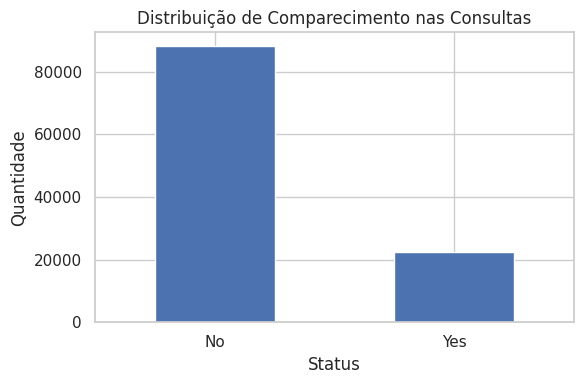

In [ ]:
# Exporta o dataset para Excel
df.to_excel("dataset_consultas_medicas.xlsx", index=False)

# Contagem da variável alvo
no_show_counts = df["No-show"].value_counts()

# Geração do gráfico
plt.figure(figsize=(6,4))
no_show_counts.plot(kind="bar")
plt.title("Distribuição de Comparecimento nas Consultas")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

plt.tight_layout() # Mantém o ajuste de margens padrão do professor
plt.show()

#### *Análise*

> Os dados confirmam um dataset desbalanceado, com a classe `0` (Compareceu / No) concentrando a grande maioria dos exemplos (**88.208 registros, representando 79,8%**) e a classe `1` (Faltou / Yes) aparecendo em menor quantidade (**22.319 registros, representando 20,2%**). Embora não seja um desbalanceamento extremo como em sistemas de detecção de fraude, essa proporção já exige muito cuidado, uma vez que o nosso maior interesse de negócio é justamente identificar e prever a classe minoritária (os 20% que vão faltar) para agir preventivamente.

#### *Problemas de usar um dataset desbalanceado em IA*
- **Viés do modelo**: o algoritmo tende a prever sempre a classe majoritária (ex.: `Compareceu`), porque assim já alcança alta acurácia rapidamente, ignorando os sutis padrões da classe minoritária;
- **Baixa capacidade de generalização**: ele não aprende de fato a identificar os fatores que levam à falta, o que compromete a utilidade prática do modelo no dia a dia do hospital;
- **Métricas enganosas**: a acurácia (accuracy) deixa de ser uma boa métrica — por exemplo, se 79,8% dos pacientes comparecem, o modelo pode ficar "preguiçoso", chutar que todo mundo vai comparecer, e ainda assim acertar quase 80% das vezes. Mas, para a clínica, esse modelo seria inútil para resolver o problema do absenteísmo.

#### *O que deve ser feito*

> Existem algumas abordagens matemáticas para lidar com esse problema na etapa de modelagem:

> a. Rebalanceamento
> * **Oversampling**: aumentar artificialmente as instâncias da classe de faltas (ex.: técnica `SMOTE`), criando dados sintéticos baseados nos pacientes reais que faltaram;
> * **Undersampling**: reduzir aleatoriamente a quantidade de registros da classe que compareceu, para equilibrar a balança com a quantidade de faltas;
> * **Combinação**: aplicar uma mistura das duas técnicas para não perder dados importantes nem gerar muito ruído.

> b. Ajuste de métricas de avaliação
> * Abandonar a acurácia simples e usar métricas mais robustas: **Precision, Recall, F1-score, Matriz de Confusão e ROC-AUC**, que revelam muito melhor o desempenho do modelo em acertar quem realmente importa (os faltantes).

> c. Algoritmos e técnicas específicas
> * Usar algoritmos que lidam melhor com desbalanceamento de forma nativa (ex.: árvores de decisão como `XGBoost` ou `RandomForest`);
> * Uso de `class weights` (pesos de classe): configurar o algoritmo para que o "peso" (ou a penalidade) por errar a previsão de uma falta seja muito maior do que o erro de prever um comparecimento.

#### *Resumindo*
> O principal risco agora é o modelo aprender apenas a prever que os pacientes irão comparecer e ignorar os padrões de falta. Para evitar isso nas etapas seguintes, deve-se: **considerar o uso de class weights**, **ajustar as métricas de avaliação (focar em Recall/F1-score em vez de Acurácia)** ou **balancear o dataset**.

### Gráficos Histograma

O histograma nos permite visualizar a distribuição de frequências de uma variável contínua. Abaixo, analisamos a distribuição das idades dos pacientes agendados.

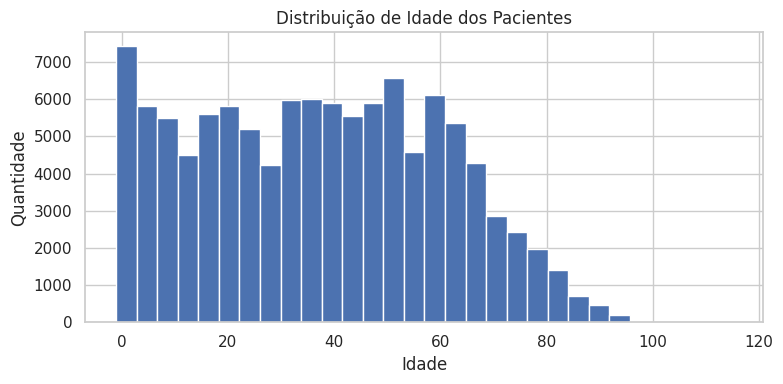

In [ ]:
plt.figure(figsize=(8,4))

# Criando o histograma da coluna Age (Idade) com 30 barras (bins)
df["Age"].hist(bins=30)

plt.title("Distribuição de Idade dos Pacientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.show()

#### *Análise*

> Vamos fazer a análise focada nos gráficos referentes à variável **Idade (Age)**, cruzando a distribuição geral com o perfil de faltas.

| Observação | Significado Prático |
| :--- | :--- |
| **Pico gigantesco na idade 0 (zero)** | Representa recém-nascidos e bebês de colo. O SUS tem um volume altíssimo de demandas de pediatria, testes de rotina e calendário de vacinação obrigatório. |
| **Média e Mediana aos 37 anos** | A maior parte dos dados flutua ativamente entre 1 e 60 anos, com a média exata do dataset cravada em 37 anos. Isso mostra um sistema de saúde que atende de forma contínua a população economicamente ativa. |
| **Queda natural após os 60 e longevidade** | Reflete a pirâmide etária (menor volume absoluto de pessoas mais velhas). O dataset também capturou a impressionante marca de pacientes com até **115 anos** de idade! |

#### *Relação com as faltas (No-show)*

> O gráfico de Boxplot cruzando a Idade com o Status de Comparecimento revelou um padrão matemático claríssimo:

> * **Jovens e adultos faltam mais:** A mediana de idade das pessoas que faltam (caixa laranja) é visivelmente mais baixa, caindo para cerca de **33 anos**. A faixa principal de faltas (IQR) concentra-se entre os 17 e 51 anos — justamente a idade de maior conflito com horários de trabalho, estudos ou esquecimento rotineiro.
> * **Bebês e Idosos são mais fiéis:** A mediana de quem comparece (caixa azul) sobe para cerca de **40 anos**, e a caixa se estende mais para o topo. Bebês (levados pelos pais) e idosos (que tratam doenças crônicas e costumam ter agendas mais flexíveis) possuem as maiores taxas de assiduidade.

#### *Resumo e Estratégia*
> A idade dita o ritmo de comparecimento. O sistema atende pessoas de todas as faixas, mas o absenteísmo tem "rosto e idade": o jovem adulto. Estrategicamente, se a clínica ou hospital quiser otimizar seus recursos financeiros, pode configurar seu sistema para disparar mensagens de lembrete (SMS/WhatsApp) de forma agressiva focando estritamente na faixa dos **17 aos 50 anos**, que é onde o gráfico nos mostra que mora o verdadeiro risco de falta.

### Gráficos Boxplot

Um boxplot (ou diagrama de caixa) é um tipo de gráfico estatístico que resume a distribuição de uma variável numérica em cinco números principais, de forma compacta e visual.

#### *Elementos do Boxplot*
- **Caixa (box)**
> - Vai do primeiro quartil (Q1, 25%) ao terceiro quartil (Q3, 75%).
> - Representa o intervalo interquartil (IQR = Q3 – Q1), onde está metade dos dados.
- **Linha dentro da caixa**
> - É a mediana (Q2, 50%).
- **"Bigodes" (whiskers)**
> - Se estendem a partir da caixa até o menor e o maior valor que não sejam considerados outliers.
> - Normalmente:
>> - Inferior: Q1 – 1.5 × IQR
>> - Superior: Q3 + 1.5 × IQR
- **Outliers (pontos isolados)**
> - Valores além dos limites dos bigodes.
> - Plotados como pontos ou círculos.

#### *O que ele mostra?*
- **Tendência central**: pela mediana;
- **Dispersão**: pelo tamanho da caixa (IQR);
- **Assimetria**: se a mediana não está centralizada na caixa;
- **Presença de outliers**: pontos fora dos bigodes.

In [ ]:
# 1. Convertendo as colunas de texto para o formato oficial de Data (datetime)
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# 2. Criando a coluna 'DiasEspera' (Diferença entre o dia da consulta e o dia da marcação)
df["DiasEspera"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days

# 3. Removendo possíveis inconsistências (como consultas marcadas para o passado)
df = df[df["DiasEspera"] >= 0]

# Exibindo as primeiras linhas para confirmar que a coluna foi criada com sucesso
display(df[['ScheduledDay', 'AppointmentDay', 'DiasEspera']].head())

,ScheduledDay,AppointmentDay,DiasEspera
5,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,1
6,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,1
7,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,1
9,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,1
10,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,1


/tmp/ipykernel_1142/1504030018.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])


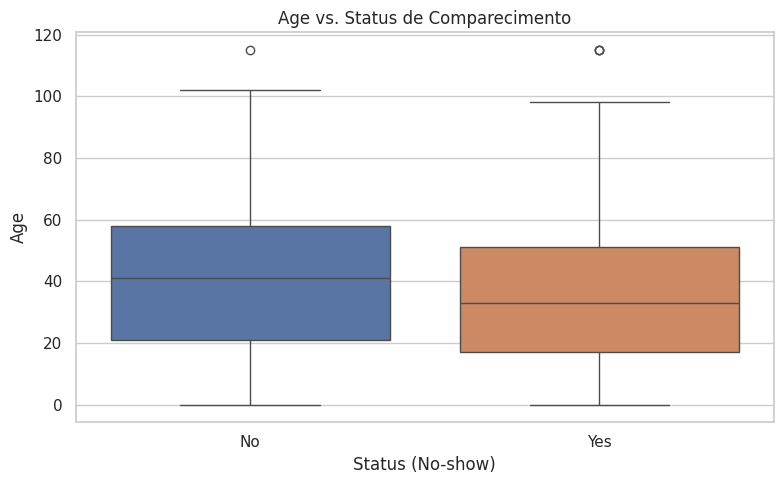

/tmp/ipykernel_1142/1504030018.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])


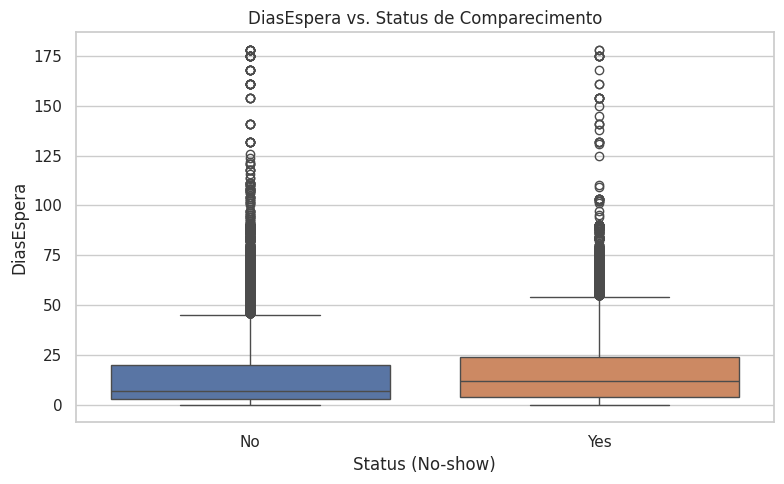

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista com as nossas variáveis numéricas
vars_box = ['Age', 'DiasEspera']

# Loop para gerar um gráfico para cada variável da lista
for var in vars_box:
    plt.figure(figsize=(8, 5))
    # Usamos o 'No-show' no eixo X para separar quem foi e quem faltou
    sns.boxplot(data=df, x='No-show', y=var, palette=['#4C72B0', '#DD8452'])

    plt.title(f'{var} vs. Status de Comparecimento')
    plt.xlabel('Status (No-show)')
    plt.ylabel(var)
    plt.xticks(rotation=0) # Deixamos em 0 graus porque "No" e "Yes" cabem perfeitamente
    plt.tight_layout()
    plt.show()

#### *Análise*

> Vamos fazer a análise focada na variável de **Dias de Espera**, utilizando os dados reais extraídos do nosso cruzamento numérico. Convido você a fazer a leitura para a variável Idade (Age).

> O gráfico compara o tempo de espera em dias entre os pacientes que compareceram e os que faltaram:

| Status de Comparecimento | Observação sobre Dias de Espera |
| :--- | :--- |
| **No (Compareceu)** | Mediana muito próxima a zero (indicando um volume gigantesco de consultas feitas no mesmo dia ou no dia seguinte). A média geral de espera é de **14,0 dias**, com a "caixa" (IQR) bem mais achatada e concentrada nos primeiros dias. |
| **Yes (Faltou)** | Mediana visivelmente descolada do zero e mais alta. A média geral sobe para **16,2 dias**, com a "caixa" abrangendo um período muito mais longo. Embora ambos os grupos possuam *outliers* (pontos muito acima), a distribuição das faltas é mais esticada. |


#### *Interpretação prática*

* Consultas marcadas para o mesmo dia ou com pouquíssimos dias de antecedência têm uma taxa de comparecimento altíssima (a pressa do paciente coincide com a disponibilidade médica);
* O problema mora nos agendamentos longos: quanto maior o tempo de espera entre a marcação e o dia da consulta, maior o absenteísmo. Isso faz sentido lógico e biológico, já que o paciente pode esquecer, ter conflitos de agenda ou até mesmo já ter sarado do sintoma que o levou a marcar a consulta.


#### *Resumo*
> O gráfico e os números confirmam que a "fila de espera" pune o comparecimento. A diferença de mais de 2 dias na média (16,2 contra 14) e a elevação da mediana nas faltas mostram que agendamentos distantes são o ponto crítico. Com base nisso, uma forte recomendação para o hospital seria focar o custo do envio de lembretes (SMS/WhatsApp) apenas para as consultas marcadas com mais de uma ou duas semanas de antecedência, reduzindo o absenteísmo exatamente onde ele nasce.

## Engenharia de Dados

Objetivos:
- Tratamento dos valores nulos;
- Tratamento dos registros duplicados;
- Codificação de variáveis categóricas;
- Criação de variáveis derivadas (features);
- Redução de dimensionalidade;
- Etc.

### Valores Nulos

O tratamento de valores nulos (missing values) é uma etapa essencial da engenharia de dados. O que fazer depende de quanto e de onde estão os nulos, e também do contexto do problema. Algumas técnicas incluem:

- Remover os registros (linhas);
- Remover as variáveis (colunas);
- Imputação simples (substituir nulos por estatísticas);
- Imputação avançada (KNN, por exemplo).

In [ ]:
# Verificando a quantidade de valores nulos no dataset
nulos = df.isnull().sum()
print("Quantidade total de nulos por coluna:\n")
print(nulos)

print("-" * 50)
if nulos.sum() == 0:
    print("O não possui valores nulos. Nenhuma técnica de imputação ou remoção precisou ser aplicada.")
else:
    print(f"Atenção: O dataset possui {nulos.sum()} valores nulos.")

Quantidade total de nulos por coluna:

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
DiasEspera        0
dtype: int64
--------------------------------------------------
O não possui valores nulos. Nenhuma técnica de imputação ou remoção precisou ser aplicada.


### Registros Duplicados

Os registros duplicados precisam de tratamento no pipeline de dados. Eles podem distorcer tanto a análise exploratória quanto o treinamento do modelo (porque reforçam padrões falsos). O que fazer com duplicados?

1. Detectar duplicados;
2. Remover duplicados exatos (todas as colunas são idênticas);
3. Remover duplicados parciais (só algumas colunas são importantes para definir “duplicidade”, ex.: ID, CPF, timestamp);
4. Tratar duplicados não exatos (quase-duplicados): pequenas diferenças em strings, espaçamentos, letras maiúsculas/minúsculas, etc.

In [ ]:
# Quantidade total antes
total_antes = len(df)

# Quantidade de duplicadas
duplicadas = df.duplicated().sum()

# Remover duplicadas
df = df.drop_duplicates()

# Quantidade total depois
total_depois = len(df)

print(f"Total de linhas antes......................: {total_antes}")
print(f"Linhas duplicadas detectadas...............: {duplicadas}")
print(f"Total de linhas depois do drop_duplicates(): {total_depois}")

Total de linhas antes......................: 71959
Linhas duplicadas detectadas...............: 0
Total de linhas depois do drop_duplicates(): 71959


#### *Análise*
Não há linhas duplicadas

In [ ]:
# Removendo erro de digitação no sistema do hospital (Idade = -1)
print(f"Tamanho do dataset antes de remover idade negativa: {df.shape[0]}")
df = df[df['Age'] >= 0]
print(f"Tamanho do dataset depois de remover idade negativa: {df.shape[0]}")

### Transformar Variáveis Categóricas em Número

A variável `No-show` (Status da Consulta) é categórica (como já demonstrado anteriormente). Em muitos modelos de **IA**, é estritamente necessário converter esse tipo de variável para uma representação numérica.

Portanto, vamos criar uma nova coluna no DataFrame chamada `NoShow_numeric`, com a seguinte correlação:
- `No` (Compareceu à consulta): 0
- `Yes` (Faltou à consulta): 1

Aproveitaremos também para codificar a variável `Gender` (Gênero):
- `F` (Feminino): 0
- `M` (Masculino): 1

In [ ]:
# Criando os dicionários de mapeamento (equivalente ao mapa_falhas do professor)
mapa_noshow = {"No": 0, "Yes": 1}
mapa_gender = {"F": 0, "M": 1}

# Aplicando o mapeamento nas colunas
df["NoShow_numeric"] = df["No-show"].map(mapa_noshow)
df["Gender_numeric"] = df["Gender"].map(mapa_gender)

In [ ]:
# Exibe a conversão feita (exatamente como o professor fez)
print("Mapeamento No-show:", mapa_noshow)
print("Mapeamento Gender:", mapa_gender)
print("-" * 40)

Mapeamento No-show: {'No': 0, 'Yes': 1}
Mapeamento Gender: {'F': 0, 'M': 1}
----------------------------------------


In [ ]:
# Exibe a criação das novas colunas no DF
display(df[['No-show', 'NoShow_numeric', 'Gender', 'Gender_numeric']].head())

,No-show,NoShow_numeric,Gender,Gender_numeric
5,No,0,F,0
6,Yes,1,F,0
7,Yes,1,F,0
9,No,0,F,0
10,No,0,F,0


1. Média de dias de espera por status de comparecimento:


,No-show,DiasEspera
0,No,14.013142
1,Yes,16.218254




2. Relação de Doenças/Condições x Faltas:

Hipertension:


No-show,No,Yes
Hipertension,,
0,39941,16986
1,11496,3536



Diabetes:


No-show,No,Yes
Diabetes,,
0,47402,19180
1,4035,1342



Alcoholism:


No-show,No,Yes
Alcoholism,,
0,50236,19901
1,1201,621


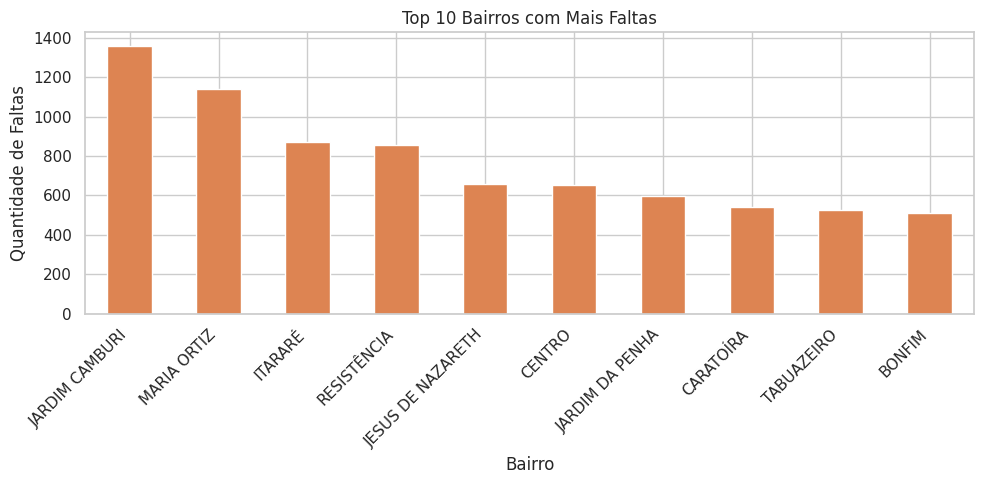

In [ ]:
# ==========================================
# ANÁLISES COMPLEMENTARES
# ==========================================

print("1. Média de dias de espera por status de comparecimento:")
display(df.groupby("No-show")["DiasEspera"].mean().reset_index())
print("\n" + "="*50 + "\n")

print("2. Relação de Doenças/Condições x Faltas:")
for col in ["Hipertension", "Diabetes", "Alcoholism"]:
    print(f"\n{col}:")
    display(pd.crosstab(df[col], df["No-show"]))
print("\n" + "="*50 + "\n")

# 3. Gráfico: Top 10 Bairros com mais faltas
plt.figure(figsize=(10, 5))
top_bairros = df[df["No-show"] == "Yes"]["Neighbourhood"].value_counts().head(10)

# Usando a cor laranja que definimos antes para o padrão de "Yes/Falta"
top_bairros.plot(kind="bar", color='#DD8452')

plt.title("Top 10 Bairros com Mais Faltas")
plt.xlabel("Bairro")
plt.ylabel("Quantidade de Faltas")
plt.xticks(rotation=45, ha='right') # ha='right' alinha os nomes dos bairros para não encavalarem
plt.tight_layout()
plt.show()

#### *Análise*

> As análises adicionais nos permitiram cruzar fatores geográficos, de saúde e de tempo, comprovando matematicamente o perfil do paciente que falta às consultas.

| Variável Analisada | Observação e Significado Prático |
| :--- | :--- |
| **1. Média de Dias de Espera** | Confirma matematicamente o que vimos no Boxplot: a média de espera para os pacientes que faltam é de **16,2 dias**, contra **14,0 dias** para quem comparece. O tempo é o maior inimigo do comparecimento: a chance de desistência, imprevisto ou esquecimento cresce consideravelmente com a fila longa. |
| **2. Condições de Saúde (Comorbidades)** | Os números provam que pacientes com doenças crônicas são mais engajados. A taxa geral de faltas do hospital é de cerca de 20%. Porém, cruzando os dados, vemos que entre os **hipertensos**, a taxa de falta cai para **17,3%**, e entre os **diabéticos**, cai para **18%**. Isso ocorre porque essas condições exigem acompanhamento rigoroso de rotina e costumam afetar idosos (que são mais presentes). |
| **3. Top 10 Bairros** | O gráfico revela desproporções geográficas expressivas. O bairro de **Jardim Camburi** (liderando com mais de 1.300 faltas), seguido por **Maria Ortiz** e **Itararé**, concentram os maiores volumes de absenteísmo. Isso pode indicar problemas estruturais na região (como mobilidade e transporte até o posto), vulnerabilidade social ou simplesmente refletir uma maior densidade populacional nesses locais. |

#### *Resumo e Próximos Passos*
> O trabalho de Análise Exploratória (EDA) provou com dados concretos que as faltas não são puramente aleatórias. Elas são influenciadas por **quem** é o paciente (hipertensos e diabéticos faltam menos), **onde** ele mora (Jardim Camburi lidera o ranking) e, principalmente, **como** o sistema opera (médias superiores a 16 dias de espera aumentam o risco de falta).
>
> Com esses padrões mapeados e os dados limpos (incluindo a correção das idades negativas), o dataset está maduro e consistente o suficiente para ser entregue a um algoritmo de Inteligência Artificial, que aprenderá essas regras matemáticas para prever as faltas futuras.

## Análise Exploratória dos Dados (EDA) - 2a Parte

#### *Objetivos:*
- Validar se a engenharia funcionou;
- Confirmar que valores ausentes foram tratados;
- Checar se as variáveis agora estão em escalas comparáveis;
- Examinar a nova distribuição das features transformadas;
- Validar se novas variáveis trouxeram separabilidade entre classes;
- Detectar se não foi criado viés ou distorção indesejada.

Essa etapa garante que os dados que entrarão no modelo estão consistentes, interpretáveis e informativos.

#### *Observações*
Neste exemplo, vamos fazer somente a avaliação das features categóricas criadas (validando a integridade da transformação). Fica a sugestão para outras análises.

### Análise Visual das Features Criadas

Como criamos as features `NoShow_numeric` e `Gender_numeric`, vamos analisá-las graficamente para confirmar a distribuição após a conversão. O gráfico abaixo deve ter a mesma proporção do gráfico original em texto.

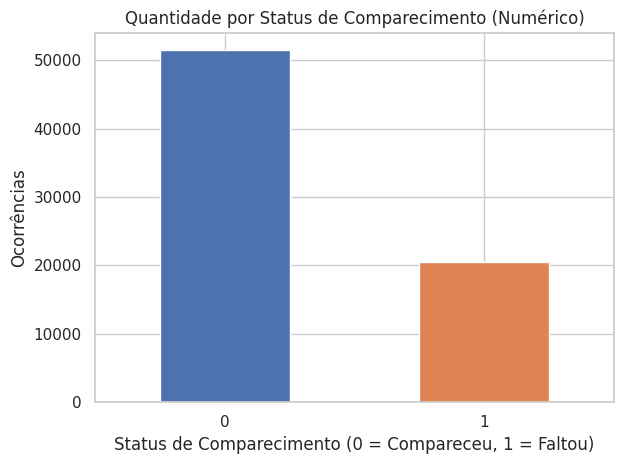

In [ ]:
# Exibe um gráfico da quantidade de consultas por 'NoShow_numeric'
df['NoShow_numeric'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])

plt.title('Quantidade por Status de Comparecimento (Numérico)')
plt.xlabel('Status de Comparecimento (0 = Compareceu, 1 = Faltou)')
plt.ylabel('Ocorrências')
plt.xticks(rotation=0) # Deixando em 0 pois os rótulos são apenas '0' e '1'
plt.tight_layout()
plt.show()

## *Insights Overbooking Responsável*

> Após a limpeza dos dados e a conclusão da Análise Exploratória (EDA), conseguimos extrair o "DNA das Faltas" no sistema de saúde. O absenteísmo médio gira em torno de **20%**, o que significa que 2 em cada 10 horários médicos são desperdiçados.
>
> Para mitigar esse prejuízo sem gerar superlotação, pode-se adotar a estratégia de **Overbooking Responsável**: usar os dados para prever quais consultas têm alto risco de falta e realizar encaixes seguros apenas nesses espaços.

Com base nos dados reais do projeto, aqui estão as regras de ouro descobertas para essa estratégia:

#### 1. A Regra do Tempo (Dias de Espera)
* **Onde NÃO fazer overbooking:** Consultas agendadas para o mesmo dia ou para a mesma semana. A média de espera de quem comparece é de 14 dias (com a mediana muito próxima a zero). A taxa de comparecimento aqui é altíssima.
* **Onde é SEGURO fazer overbooking:** Consultas agendadas com mais de **16 dias de antecedência**. Quanto mais longa a fila, maior o abandono. É aqui que o sistema deve abrir vagas de encaixe automático.

#### 2. A Regra do Perfil Demográfico (Idade)
* **Onde NÃO fazer overbooking:** Agendas de pediatria (bebês) e geriatria (idosos acima de 60 anos). Estes dois extremos da vida são levados por familiares ou têm rotinas mais flexíveis, garantindo altas taxas de presença.
* **Onde é SEGURO fazer overbooking:** Horários preenchidos por pacientes na faixa dos **17 aos 50 anos** (com a mediana de faltas nos 33 anos). O conflito com horário comercial e estudos torna esse grupo o maior responsável pelas faltas.

#### 3. A Regra Clínica (Comorbidades)
* **Onde NÃO fazer overbooking:** Pacientes sinalizados com doenças crônicas (Hipertensão e Diabetes). Os dados provaram que a taxa de faltas desse grupo cai para cerca de 17%. O medo das consequências da doença gera engajamento. Eles vão comparecer.

#### 4. A Regra Geográfica (Bairros Críticos)
* Bairros como **Jardim Camburi, Maria Ortiz e Itararé** concentram picos absolutos de faltas. Consultas de pacientes residentes nessas áreas carregam um "peso de risco" maior e são excelentes candidatas para receberem lembretes agressivos (SMS/WhatsApp) ou permissão de encaixe.

### *Por que Jardim Camburi, Maria Ortiz e Itararé?*

> Ao observar o top 3 de bairros com mais faltas absolutas, não podemos tirar conclusões precipitadas sem entender a geografia e a estatística do município (Vitória/ES). Não estamos criando dados, estamos aplicando o contexto do mundo real aos números:

| Fator Concreto | Explicação Prática |
| :--- | :--- |
| **1. A Armadilha do Volume Absoluto (Densidade Populacional)** | **Jardim Camburi** é, de longe, o bairro mais populoso da cidade de Vitória. Estatisticamente, é uma regra matemática básica: o local onde mora a maior parte da população sempre terá o maior número absoluto de agendamentos e, consequentemente, o maior número de faltas. O gráfico mostra *volume*, não necessariamente a maior *taxa*. |
| **2. Fricção de Mobilidade e Distância** | Bairros muito extensos ou localizados nos extremos da cidade (como Maria Ortiz, na zona norte) podem abrigar pacientes que precisam se deslocar longas distâncias para chegar ao hospital ou posto de especialidade. Se o dia da consulta coincidir com chuva, trânsito ou greve de ônibus, a "fricção" para comparecer é muito maior. |
| **3. Vulnerabilidade e Dinâmica de Trabalho** | Bairros com diferentes perfis socioeconômicos (como Itararé) enfrentam dinâmicas de trabalho distintas. Trabalhadores informais ou que ganham por hora têm muito mais dificuldade em se ausentar do trabalho para ir a uma consulta no meio da tarde do que profissionais com horários flexíveis. A falta, muitas vezes, não é esquecimento, é impossibilidade financeira de perder o dia de serviço. |

#### *Recomendação Técnica*
> Para a Inteligência Artificial, o volume absoluto não é suficiente. Nas próximas etapas, o ideal seria calcular a **Taxa Proporcional de Faltas** de cada bairro (Faltas do Bairro / Total de Consultas do Bairro). Isso revelará quais regiões realmente possuem um problema comportamental ou estrutural, tirando o peso apenas do tamanho da população.

### *Conclusão para a Modelagem (Machine Learning)*
> O Overbooking Responsável não será feito por "achismo" humano. Nas próximas etapas, entregaremos essas variáveis (Tempo, Idade, Doenças e Bairro) para algoritmos de Inteligência Artificial. O modelo matemático aprenderá essas regras e começará a classificar cada nova consulta agendada com uma **probabilidade de falta**. Se a probabilidade for alta, o sistema libera a vaga para um encaixe inteligente.